In [1]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d

# Global settings
INPUT_FILENAME = "Nello.wav"     # place Nello.wav in same folder
N_BLOCK = 256
CUTOFF_FREQ_K = 10
BUTTERWORTH_ORDER = 4
PITCH_SHIFT_FACTOR = 1.25

plt.rcParams["axes.unicode_minus"] = False


In [2]:
class CustomDFT:
    def __init__(self, N):
        self.N = N
        k_matrix, n_matrix = np.meshgrid(np.arange(N), np.arange(N))
        self.W_dft = np.exp(-2j * np.pi * k_matrix * n_matrix / N)
        self.W_idft = np.exp(2j * np.pi * k_matrix * n_matrix / N) / N

    def dft(self, x):
        x = np.asarray(x, dtype=np.complex128)
        return np.dot(x, self.W_dft)

    def idft(self, X):
        X = np.asarray(X, dtype=np.complex128)
        return np.real(np.dot(X, self.W_idft))

def ideal_lowpass_filter(N, cutoff_k):
    H = np.zeros(N)
    if cutoff_k >= 0:
        end = min(N, cutoff_k + 1)
        H[:end] = 1.0
        if cutoff_k > 0:
            H[-cutoff_k:] = 1.0
    return H

def ideal_highpass_filter(N, cutoff_k):
    H = np.ones(N)
    if cutoff_k >= 0:
        end = min(N, cutoff_k + 1)
        H[:end] = 0.0
        if cutoff_k > 0:
            H[-cutoff_k:] = 0.0
    return H

def butterworth_lowpass_filter(N, cutoff_k, order):
    if cutoff_k <= 0:
        H = np.zeros(N); H[0]=1.0; return H
    D0 = float(cutoff_k)
    k_idx = np.arange(N)
    D = np.minimum(k_idx, N - k_idx)
    H = 1.0 / (1.0 + (D/D0)**(2.0 * order))
    return H

def butterworth_highpass_filter(N, cutoff_k, order):
    return 1.0 - butterworth_lowpass_filter(N, cutoff_k, order)


In [ ]:
def read_wav_norm(fname):
    fs, data = wavfile.read(fname)
    dtype = data.dtype
    if data.ndim == 1:
        pass
    else:
        data = data.mean(axis=1)
    if dtype == np.uint8:
        x = (data.astype(np.float64) - 128)/128.0
    elif dtype == np.int16:
        x = data.astype(np.float64)/32768.0
    else:
        x = data.astype(np.float64)
    return fs, x, dtype

def write_wav_from_float(fname, fs, x, dtype):
    x = np.clip(x, -1.0, 1.0)
    if dtype == np.uint8:
        out = np.round(x*128 + 128).astype(np.uint8)
    elif dtype == np.int16:
        out = np.round(x*32767).astype(np.int16)
    else:
        out = x.astype(np.float32)
    wavfile.write(fname, fs, out)

def pitch_shift_filter(X, factor):
    N = len(X)
    half = N // 2
    half_len = half + 1
    
    idx = np.arange(half_len)
    k_new = idx * factor
    
    r_interp = interp1d(idx, X[:half_len].real, kind='linear', fill_value=0, bounds_error=False)
    i_interp = interp1d(idx, X[:half_len].imag, kind='linear', fill_value=0, bounds_error=False)
    
    Y_half_interp = r_interp(k_new) + 1j * i_interp(k_new)
    
    Y = np.zeros(N, dtype=np.complex128)
    Y[:half_len] = Y_half_interp
    
    for k in range(1, half_len):
        Y[N - k] = np.conj(Y[k])
    
    return Y


In [4]:
def process_audio(input_file, output_file, N, filter_func=None, cutoff_k=0, order=0, pitch=False, factor=1.0, window=None):
    try:
        fs, data, dtype = read_wav_norm(input_file)
    except FileNotFoundError:
        print(f"File not found: {input_file}"); return None
    L = len(data)
    if window is None:
        win = np.ones(N)
    else:
        win = window
    dftp = CustomDFT(N)
    n_blocks = (L + N - 1)//N
    out = np.zeros(n_blocks * N, dtype=np.float64)
    H = None
    if (filter_func is not None) and (not pitch):
        if filter_func in (butterworth_lowpass_filter, butterworth_highpass_filter):
            H = filter_func(N, cutoff_k, order)
        else:
            H = filter_func(N, cutoff_k)
    for b in range(n_blocks):
        start = b * N
        seg = np.zeros(N, dtype=np.float64)
        take = min(N, max(0, L - start))
        if take > 0:
            seg[:take] = data[start:start+take]
        seg_win = seg * win
        Xk = dftp.dft(seg_win)
        if pitch:
            Yk = pitch_shift_filter(Xk, factor)
        elif H is not None:
            Yk = Xk * H
        else:
            Yk = Xk
        y = dftp.idft(Yk)
        with np.errstate(divide='ignore', invalid='ignore'):
            denom = np.where(win != 0, win, 1.0)
            y = y / denom
        out[start:start+N] = y
    out = out[:L]
    write_wav_from_float(output_file, fs, out, dtype)
    return np.abs(Xk), fs, H

def plot_spectrum(spec, N, title):
    half = N//2
    plt.figure(figsize=(8,3))
    plt.plot(np.arange(half), spec[:half])
    plt.title(title); plt.xlabel('k'); plt.ylabel('|X[k]|'); plt.grid(True); plt.show()

def plot_filter_response(N, cutoff_k, order):
    H_ilpf = ideal_lowpass_filter(N, cutoff_k)
    H_ihpf = ideal_highpass_filter(N, cutoff_k)
    H_blpf = butterworth_lowpass_filter(N, cutoff_k, order)
    H_bhpf = butterworth_highpass_filter(N, cutoff_k, order)
    plt.figure(figsize=(8,4))
    plt.plot(H_ilpf, label='ILPF')
    plt.plot(H_ihpf, label='IHPF')
    plt.plot(H_blpf, label='BLPF')
    plt.plot(H_bhpf, label='BHPF')
    plt.title('Four Filters Frequency Response'); plt.xlabel('k'); plt.ylabel('|H[k]|')
    plt.legend(); plt.grid(True); plt.show()


R1 copied to R1_b.wav
spectrum start index: 0


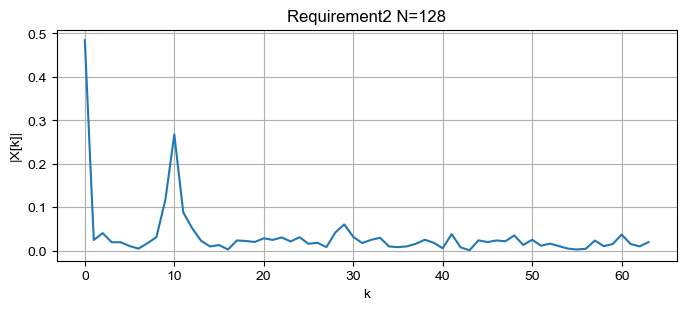

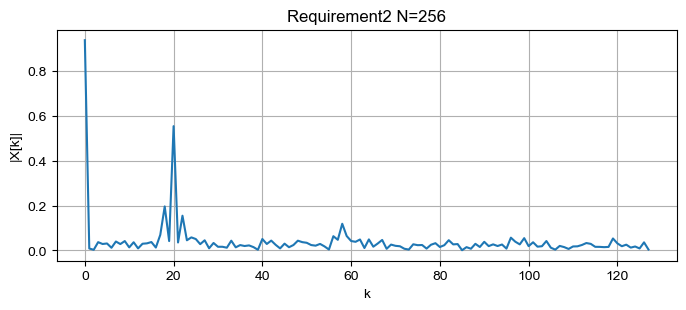

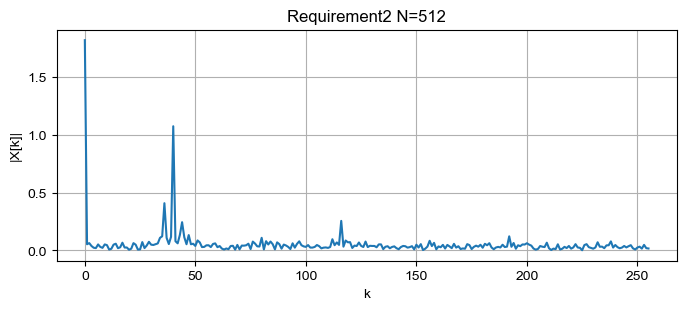

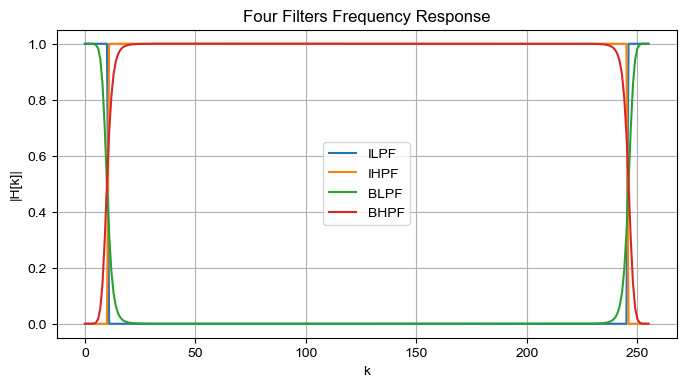

ILPF done -> R3_ILPF_N256.wav
IHPF done -> R3_IHPF_N256.wav
BLPF done -> R3_BLPF_N256.wav
BHPF done -> R3_BHPF_N256.wav


In [8]:
# Requirement 1: copy
if os.path.exists(INPUT_FILENAME):
    with open(INPUT_FILENAME,'rb') as fin, open('R1_b.wav','wb') as fout:
        fout.write(fin.read())
    print('R1 copied to R1_b.wav')
else:
    print('Nello.wav missing in working dir.')

# Requirement 2: pick non-silent middle segment for plotting spectrum
fs, data, dtype = read_wav_norm(INPUT_FILENAME)
threshold = 0.001
abs_data = np.abs(data)
non_silent = np.where(abs_data > threshold)[0]
if len(non_silent) == 0:
    start_idx = len(data)//2
else:
    start_idx = max(non_silent[0]-1000, 0)
print('spectrum start index:', start_idx)

for N_test in [128, 256, 512]:
    seg = data[start_idx:start_idx+N_test]
    if len(seg) < N_test:
        seg = np.pad(seg, (0, N_test - len(seg)))
    dftp = CustomDFT(N_test)
    spec = np.abs(dftp.dft(seg))
    plot_spectrum(spec, N_test, f'Requirement2 N={N_test}')
    process_audio(INPUT_FILENAME, f'R2_N{N_test}_b.wav', N_test)

# Requirement 3: generate 4 filtered outputs and plot filter responses
plot_filter_response(N_BLOCK, CUTOFF_FREQ_K, BUTTERWORTH_ORDER)

filters_to_test = [
    ('ILPF', ideal_lowpass_filter),
    ('IHPF', ideal_highpass_filter),
    ('BLPF', butterworth_lowpass_filter),
    ('BHPF', butterworth_highpass_filter),
]

for name, func in filters_to_test:
    outname = f'R3_{name}_N{N_BLOCK}.wav'
    if name.startswith('B'):
        _ = process_audio(INPUT_FILENAME, outname, N_BLOCK, filter_func=func, cutoff_k=CUTOFF_FREQ_K, order=BUTTERWORTH_ORDER)
    else:
        _ = process_audio(INPUT_FILENAME, outname, N_BLOCK, filter_func=func, cutoff_k=CUTOFF_FREQ_K)
    print(name, 'done ->', outname)

# Bonus: pitch shift
_ = process_audio(INPUT_FILENAME, 'R_Bonus_PitchUp.wav', N_BLOCK, pitch=True, factor=PITCH_SHIFT_FACTOR)
_ = process_audio(INPUT_FILENAME, 'R_Bonus_PitchDown.wav', N_BLOCK, pitch=True, factor=0.75)


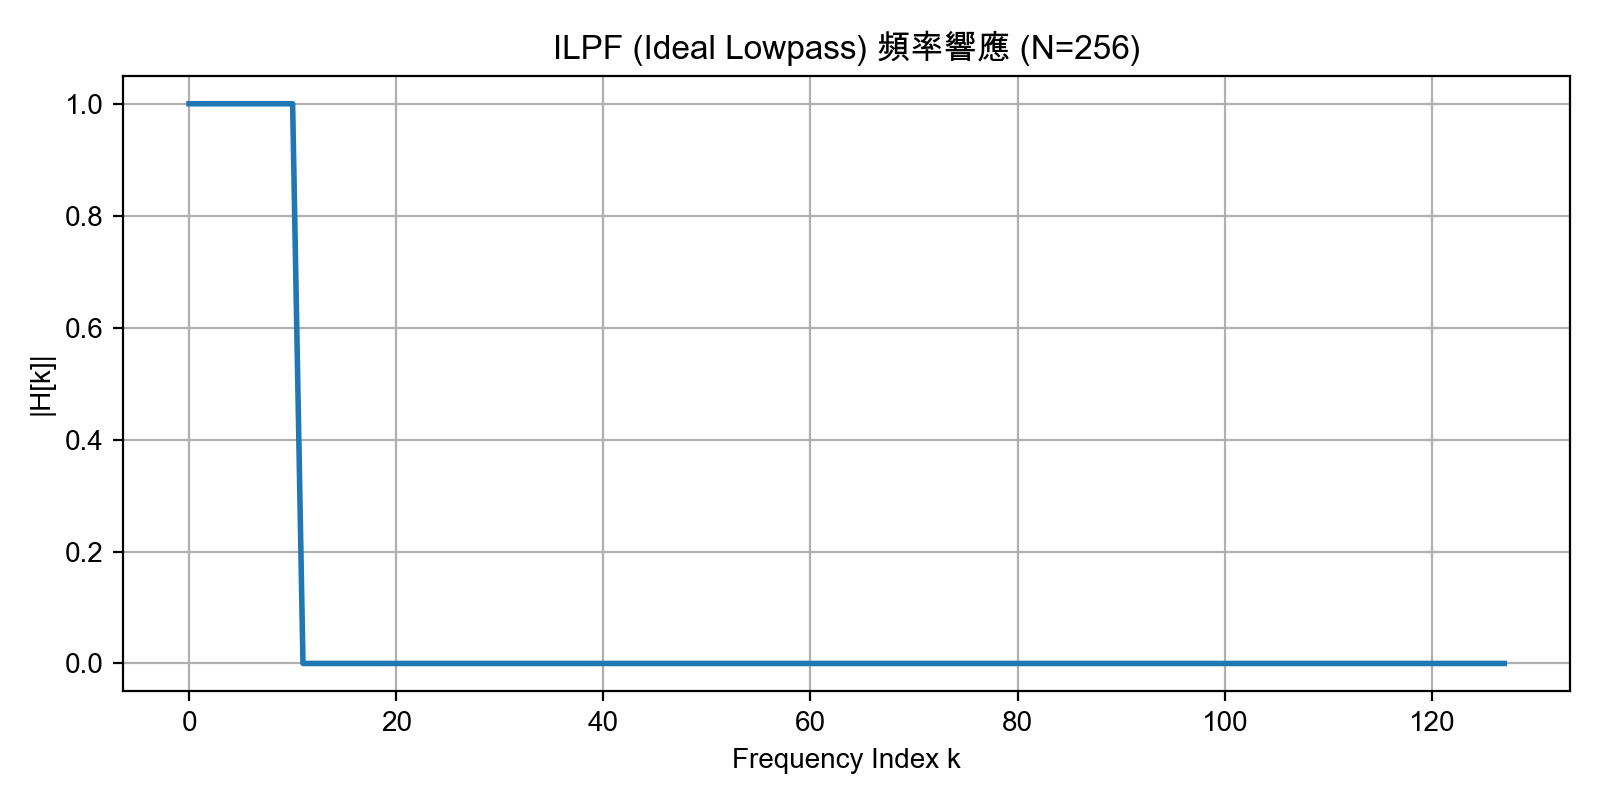

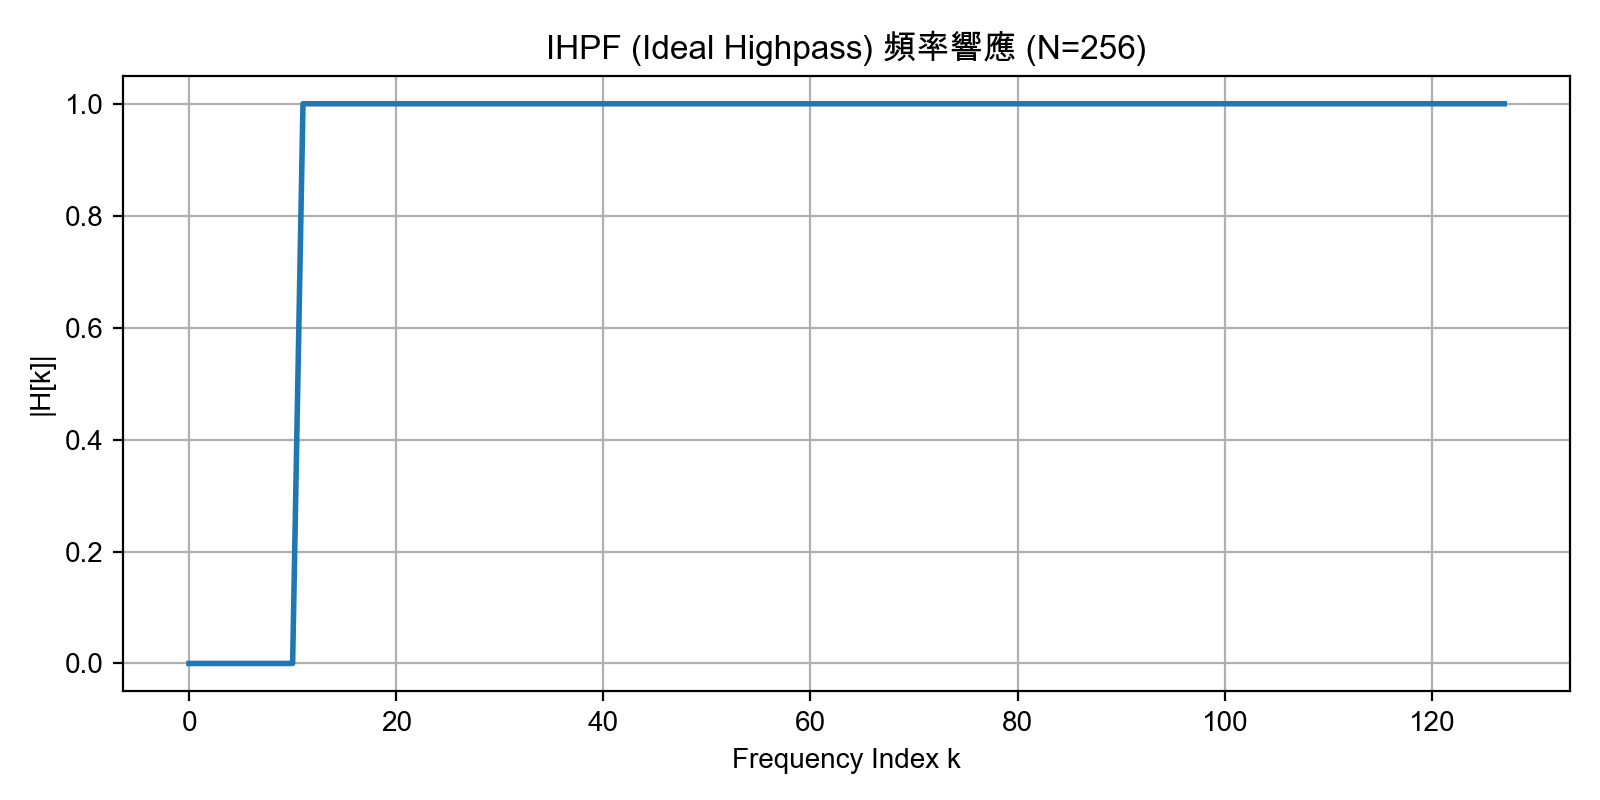

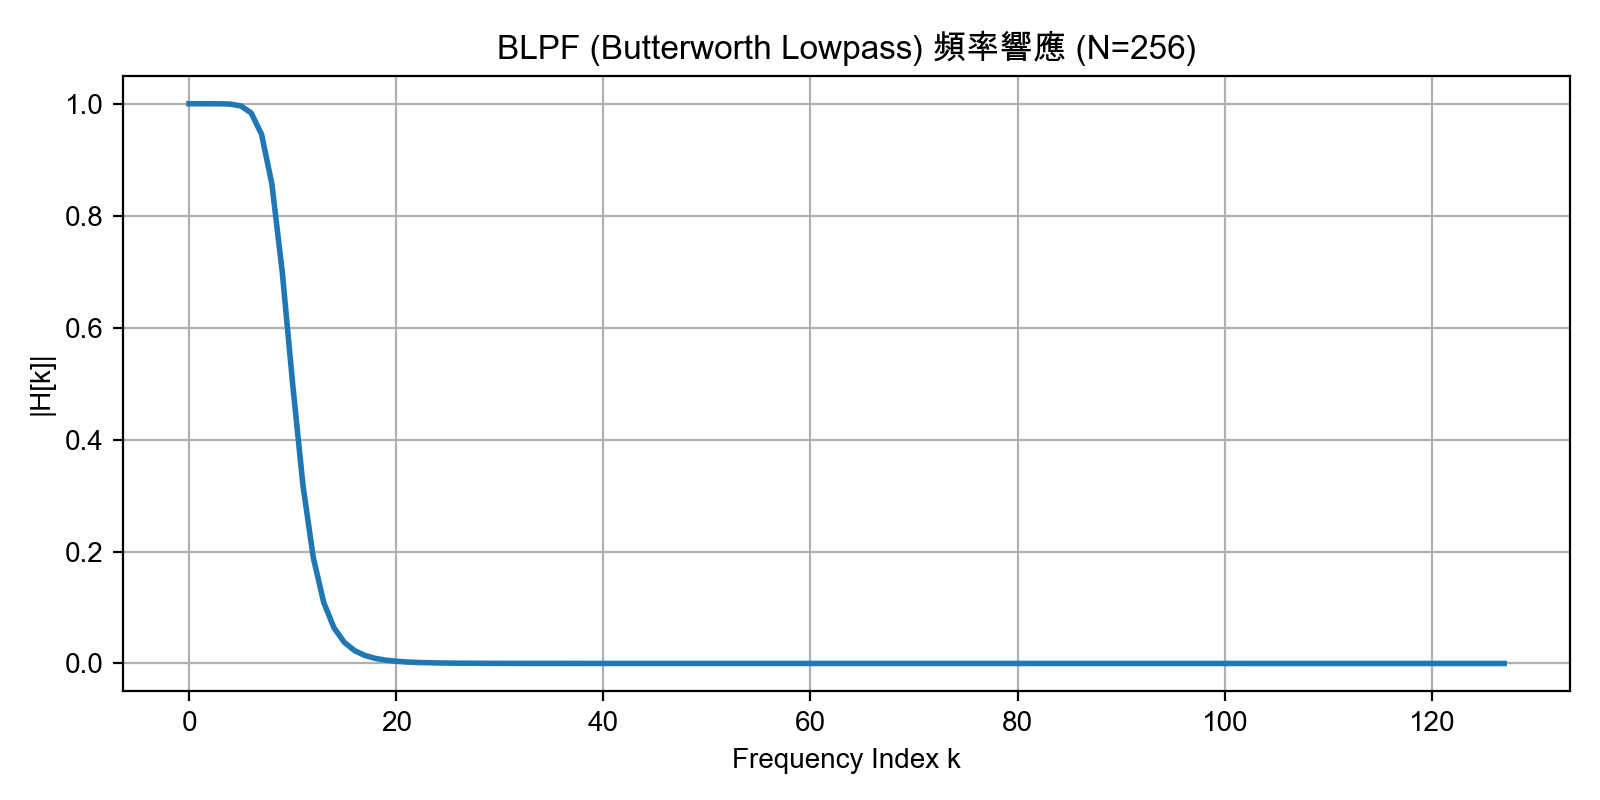

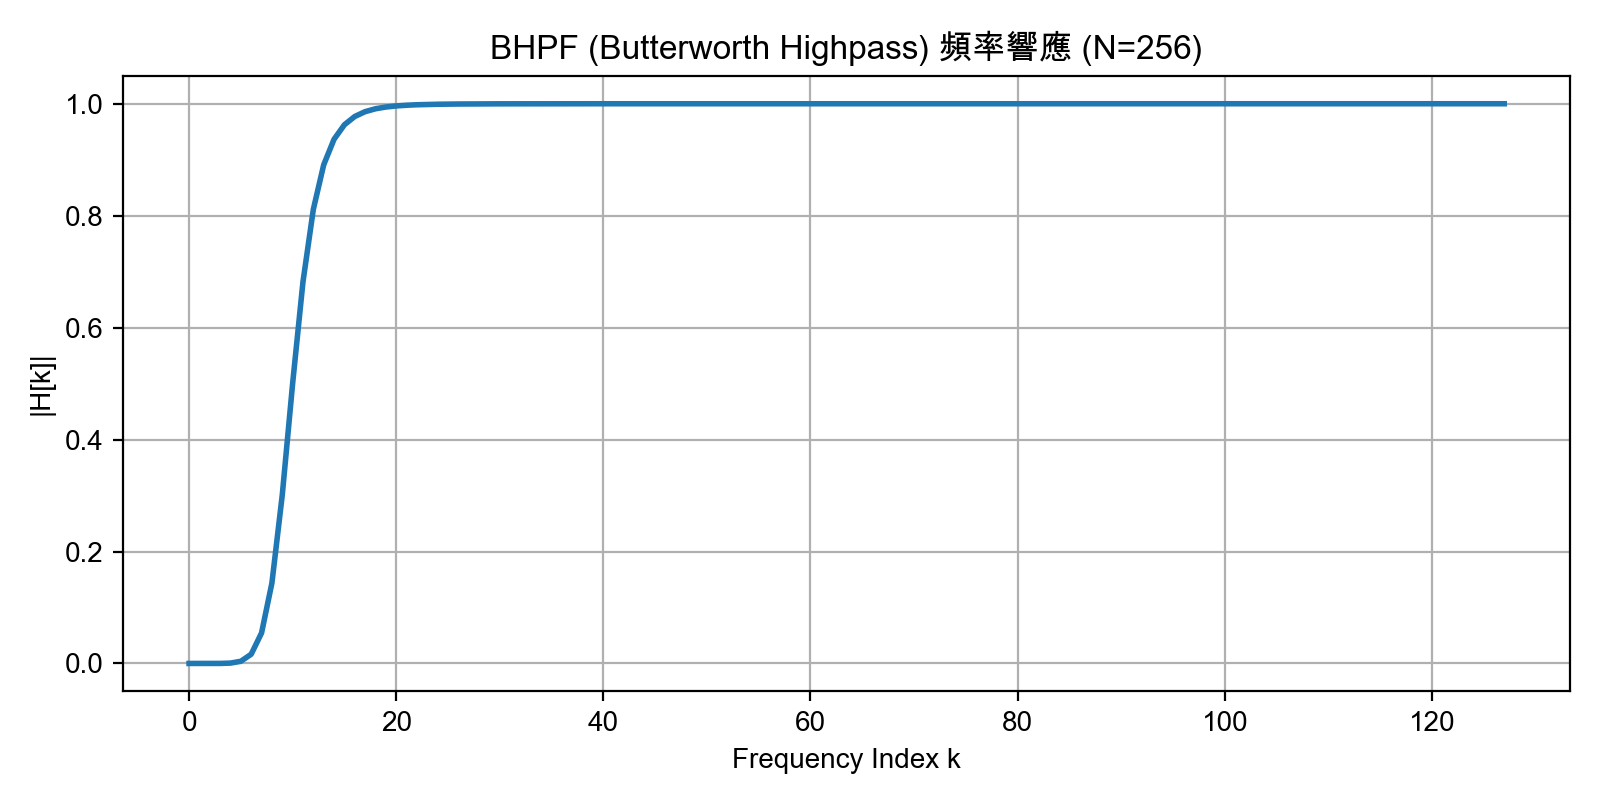

Saved filter plots: {'ILPF': 'filter_plots/ILPF_Response_N256.png', 'IHPF': 'filter_plots/IHPF_Response_N256.png', 'BLPF': 'filter_plots/BLPF_Response_N256.png', 'BHPF': 'filter_plots/BHPF_Response_N256.png'}


In [6]:
import os
from IPython.display import Image, display

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"] 
plt.rcParams["axes.unicode_minus"] = False

def plot_single_filter_response(H, name, N, filename, show=True):
    """
    繪製單一濾波器響應並儲存為圖片。
    H: 長度 N 的頻率響應陣列
    name: 濾波器名稱（字串）
    filename: 儲存檔名 (png)
    """
    plt.figure(figsize=(8,4))
    half = N // 2
    plt.plot(np.arange(half), H[:half], linewidth=2)
    plt.title(f"{name} 頻率響應 (N={N})")
    plt.xlabel("Frequency Index k")
    plt.ylabel("|H[k]|")
    plt.grid(True)
    plt.tight_layout()
    # create dir if not exists
    os.makedirs(os.path.dirname(filename) or ".", exist_ok=True)
    plt.savefig(filename, dpi=200)
    if show:
        display(Image(filename))
    plt.close()

def generate_and_save_all_filter_plots(N, cutoff_k, order, out_dir="filter_plots", show=True):
    """
    生成並儲存四張濾波器響應圖 (ILPF, IHPF, BLPF, BHPF)。
    會回傳一個 dict: {name: filepath}
    """
    os.makedirs(out_dir, exist_ok=True)

    # compute H for each filter
    H_ilpf = ideal_lowpass_filter(N, cutoff_k)
    H_ihpf = ideal_highpass_filter(N, cutoff_k)
    H_blpf = butterworth_lowpass_filter(N, cutoff_k, order)
    H_bhpf = butterworth_highpass_filter(N, cutoff_k, order)

    paths = {}
    paths['ILPF'] = os.path.join(out_dir, f"ILPF_Response_N{N}.png")
    paths['IHPF'] = os.path.join(out_dir, f"IHPF_Response_N{N}.png")
    paths['BLPF'] = os.path.join(out_dir, f"BLPF_Response_N{N}.png")
    paths['BHPF'] = os.path.join(out_dir, f"BHPF_Response_N{N}.png")

    plot_single_filter_response(H_ilpf, "ILPF (Ideal Lowpass)", N, paths['ILPF'], show=show)
    plot_single_filter_response(H_ihpf, "IHPF (Ideal Highpass)", N, paths['IHPF'], show=show)
    plot_single_filter_response(H_blpf, "BLPF (Butterworth Lowpass)", N, paths['BLPF'], show=show)
    plot_single_filter_response(H_bhpf, "BHPF (Butterworth Highpass)", N, paths['BHPF'], show=show)

    return paths

# === 使用範例（把這行放在你想產生圖的位置執行） ===
# 會在工作目錄下建立 filter_plots 資料夾，並產生四張 PNG
filter_plot_paths = generate_and_save_all_filter_plots(N_BLOCK, CUTOFF_FREQ_K, BUTTERWORTH_ORDER, out_dir="filter_plots", show=True)
print("Saved filter plots:", filter_plot_paths)
